# Capítulo 1 — Cálculo Básico para Finanças

Este capítulo constrói uma ponte entre cálculo, álgebra e decisões financeiras. A sequência conceitual é guiada por temas do Volume I de *Market Risk Analysis: Quantitative Methods in Finance*, de Carol Alexander, sem reproduzir seu texto.

**Objetivos:**

- interpretar funções, raízes, exponenciais, logaritmos, derivadas e integrais;
- transformar essas ideias em retornos, P&L, capitalização e valor presente;
- usar gradiente, Hessiana e Taylor para estudar otimização e sensibilidades;
- interpretar duration, convexidade, delta, gamma e vega em aplicações financeiras.

Em cada seção seguimos: teoria, equação, implementação, aplicação, interpretação e exercício.

## Como ler este capítulo

Cada seção segue o mesmo percurso: **Objetivo**, **Intuição**, **Formulação matemática**, **Implementação do zero**, **Implementação com biblioteca**, **Exemplo financeiro**, **Visualização**, **Interpretação**, **Armadilhas** e **Exercício**. Primeiro tente prever o comportamento pela equação; depois use o código para testar a previsão. As funções do pacote aparecem como uma segunda implementação, não como substituto da derivação.

## 1.1 — Funções, gráficos, exponencial, logaritmo e raízes

Uma função transforma uma entrada em uma saída. Em finanças, funções de preço e retorno permitem estudar crescimento, risco e pontos de equilíbrio. A exponencial representa crescimento multiplicativo; o logaritmo natural transforma multiplicações em somas:

$$e^x = \exp(x), \qquad \ln(ab)=\ln(a)+\ln(b).$$

Para uma equação quadrática $ax^2+bx+c=0$, as raízes são

$$x = \frac{-b \pm \sqrt{b^2-4ac}}{2a}.$$

**Interpretação financeira:** uma raiz pode representar o preço, taxa ou quantidade em que um lucro, fluxo de caixa ou valor presente se torna zero.

**Exercício:** altere os coeficientes da quadrática e identifique quando ela tem duas raízes reais, uma raiz real ou nenhuma raiz real.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from math import exp, log, sqrt

from quantfinance.fixed_income import (
    continuous_compounding,
    convexity,
    future_value,
    macaulay_duration,
    modified_duration,
    present_value,
)
from quantfinance.options import black_scholes_call
from quantfinance.returns import (
    log_return,
    pnl_long,
    pnl_short,
    portfolio_return,
    simple_return,
)

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

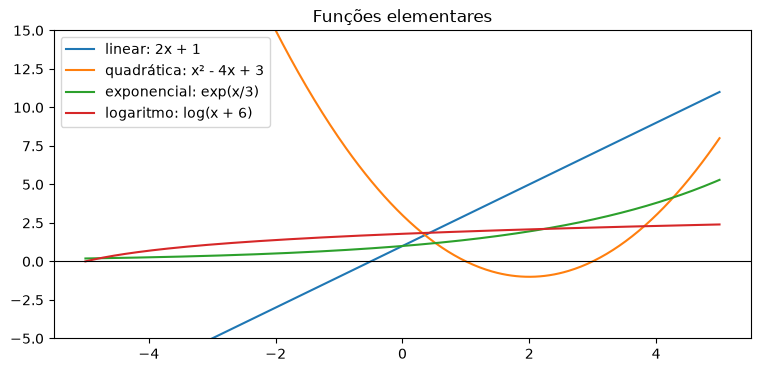

Raízes da quadrática: [3. 1.]
log(100) transforma uma escala multiplicativa: 4.605170185988092


In [2]:
x = np.linspace(-5, 5, 400)

f_linear = 2 * x + 1
f_quad = x**2 - 4 * x + 3
f_exp = np.exp(x / 3)
f_log = np.log(x + 6)

plt.figure(figsize=(9, 4))
plt.plot(x, f_linear, label="linear: 2x + 1")
plt.plot(x, f_quad, label="quadrática: x² - 4x + 3")
plt.plot(x, f_exp, label="exponencial: exp(x/3)")
plt.plot(x, f_log, label="logaritmo: log(x + 6)")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylim(-5, 15)
plt.legend()
plt.title("Funções elementares")
plt.show()

roots = np.roots([1, -4, 3])
print("Raízes da quadrática:", roots)
print("log(100) transforma uma escala multiplicativa:", np.log(100.0))

## 1.2 — Diferenciação, integração, concavidade e otimização

A derivada mede a taxa de variação local. A segunda derivada informa a curvatura: $f''(x)>0$ indica convexidade e $f''(x)<0$ indica concavidade. Um ponto estacionário satisfaz $f'(x)=0$.

$$f'(x)=\lim_{h\to 0}\frac{f(x+h)-f(x)}{h}, \qquad
f''(x)=\frac{d}{dx}f'(x).$$

A integral acumula uma quantidade ao longo de um intervalo:

$$\int_a^b f(x)\,dx = F(b)-F(a), \quad F'(x)=f(x).$$

Em finanças, a derivada de um valor em relação a um preço é uma sensibilidade; a integral pode representar fluxo acumulado, área sob uma curva de juros ou valor esperado contínuo.

**Exercício:** encontre analiticamente e numericamente os pontos estacionários de outra função cúbica e classifique-os pela segunda derivada.

In [3]:
x_sym = sp.symbols("x")
f = x_sym**3 - 6 * x_sym**2 + 9 * x_sym + 2

df = sp.diff(f, x_sym)
d2f = sp.diff(df, x_sym)
antiderivative = sp.integrate(f, x_sym)
critical = sp.solve(sp.Eq(df, 0), x_sym)

print("f'(x) =", df)
print("f''(x) =", d2f)
print("Uma integral de f(x) =", antiderivative)
print("Pontos estacionários:", critical)
for point in critical:
    curvature = sp.N(d2f.subs(x_sym, point))
    classification = "convexo/local mínimo" if curvature > 0 else "côncavo/local máximo"
    print(point, "-> f(c) =", sp.N(f.subs(x_sym, point)), "|", classification)

area = sp.integrate(f, (x_sym, 0, 1))
print("Integral definida entre 0 e 1:", area)

f'(x) = 3*x**2 - 12*x + 9
f''(x) = 6*x - 12
Uma integral de f(x) = x**4/4 - 2*x**3 + 9*x**2/2 + 2*x
Pontos estacionários: [1, 3]
1 -> f(c) = 6.00000000000000 | côncavo/local máximo
3 -> f(c) = 2.00000000000000 | convexo/local mínimo
Integral definida entre 0 e 1: 19/4


## 1.3 — Retornos, retorno de carteira, P&L e capitalização

Para um preço $P_t$, o retorno percentual simples e o log-retorno são

$$R_t=\frac{P_t}{P_{t-1}}-1, \qquad r_t=\ln\left(\frac{P_t}{P_{t-1}}\right).$$

O retorno de uma carteira linear é a soma ponderada dos retornos dos ativos:

$$R_{p,t}=\sum_{i=1}^n w_iR_{i,t}=\mathbf{w}'\mathbf{R}_t.$$

O P&L de uma posição longa é $q(P_1-P_0)$; na posição curta, o sinal é invertido. Na capitalização discreta,

$$FV=PV\left(1+\frac{r}{m}\right)^{mt},$$

enquanto na capitalização contínua,

$$FV=PV e^{rt}.$$

**Interpretação financeira:** log-retornos são aditivos no tempo, enquanto retornos simples são intuitivos para comunicar ganhos e perdas. A carteira linear mostra que pesos e exposição determinam o retorno antes de custos e efeitos não lineares.

**Exercício:** compare o retorno da carteira com pesos $[0.6,0.4]$ em dois ativos e verifique que os log-retornos acumulados reproduzem o retorno simples acumulado.

,Preço,Retorno simples,Log-retorno
0,100,NaN,NaN
1,103,0.030000,0.029559
2,101,-0.019417,-0.019608
3,106,0.049505,0.048319
4,110,0.037736,0.037041


Retorno simples acumulado: 0.10000000000000009
Log-retorno acumulado: 0.09531017980432477
exp(log total)-1: 0.09999999999999987
Retornos de uma carteira linear: [0.06 0.02]


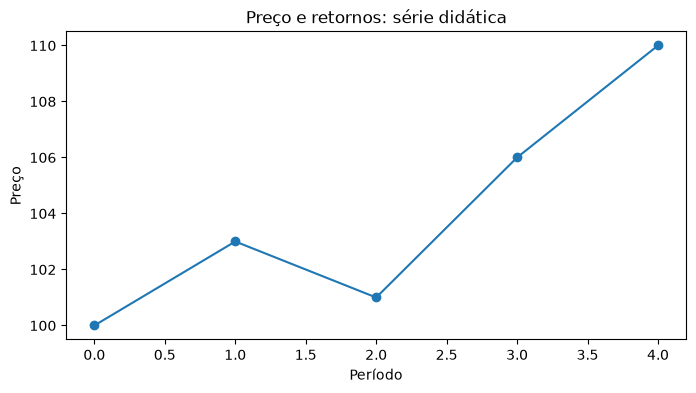

In [4]:
prices = pd.Series([100, 103, 101, 106, 110], name="Preço")

simple_r = pd.Series(simple_return(prices.to_numpy()), index=prices.index[1:])
log_r = pd.Series(log_return(prices.to_numpy()), index=prices.index[1:])

df = pd.DataFrame({"Preço": prices, "Retorno simples": simple_r, "Log-retorno": log_r})
display(df)

simple_total = prices.iloc[-1] / prices.iloc[0] - 1
log_total = log_r.sum()
portfolio_r = portfolio_return(
    np.array([[0.10, 0.00], [0.00, 0.05]]),
    np.array([0.60, 0.40]),
)

print("Retorno simples acumulado:", simple_total)
print("Log-retorno acumulado:", log_total)
print("exp(log total)-1:", np.exp(log_total) - 1)
print("Retornos de uma carteira linear:", portfolio_r)

plt.figure(figsize=(8, 4))
plt.plot(prices.index, prices.values, marker="o")
plt.title("Preço e retornos: série didática")
plt.xlabel("Período")
plt.ylabel("Preço")
plt.show()

In [5]:
quantity = 500
entry_price, exit_price = 30.0, 31.2

print("P&L long :", pnl_long(quantity, entry_price, exit_price))
print("P&L short:", pnl_short(quantity, entry_price, exit_price))

principal = 1_000.0
rate = 0.08
years = 3
print("FV discreto:", future_value(principal, rate, years))
print("PV do FV:", present_value(future_value(principal, rate, years), rate, years))
print("FV contínuo:", continuous_compounding(principal, rate, years))

P&L long : 599.9999999999997
P&L short: -599.9999999999997
FV discreto: 1259.7120000000002
PV do FV: 1000.0
FV contínuo: 1271.2491503214048


## 1.4 — Exemplo estocástico: movimento Browniano geométrico

Uma trajetória simples de preço pode ser simulada por

$$S_{t+\Delta t}=S_t\exp\left[\left(\mu-\frac{1}{2}\sigma^2\right)\Delta t+\sigma\sqrt{\Delta t}Z_t\right],$$

com $Z_t\sim N(0,1)$. O termo de drift controla o crescimento médio e $\sigma$ controla a dispersão.

**Interpretação financeira:** a simulação é um laboratório para visualizar risco de trajetória; ela não é uma previsão determinística.

**Exercício:** fixe a mesma sequência aleatória e compare trajetórias com volatilidades de 10% e 40%.

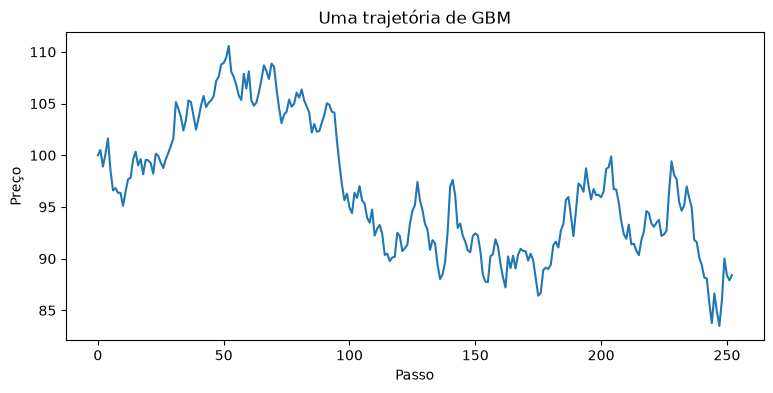

In [6]:
rng = np.random.default_rng(42)

S0 = 100
mu = 0.10
sigma = 0.25
T = 1.0
steps = 252
dt = T/steps

z = rng.standard_normal(steps)
increments = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
S = S0*np.exp(np.cumsum(np.r_[0, increments]))

plt.figure(figsize=(9,4))
plt.plot(S)
plt.title("Uma trajetória de GBM")
plt.xlabel("Passo")
plt.ylabel("Preço")
plt.show()

## 1.5 — Funções de várias variáveis, gradiente e Hessiana

Para $g(x_1,x_2)$, o gradiente reúne as derivadas parciais e a Hessiana reúne as derivadas de segunda ordem:

$$\nabla g=\begin{bmatrix}\partial g/\partial x_1\\\partial g/\partial x_2\end{bmatrix}, \qquad
H_g=\begin{bmatrix}g_{11}&g_{12}\\g_{21}&g_{22}\end{bmatrix}.$$

Em um ponto estacionário, $\nabla g=0$. Uma Hessiana definida positiva indica um mínimo local; definida negativa, um máximo local. Em otimização de carteiras, essa curvatura representa como o risco muda quando os pesos são deslocados.

**Exercício:** altere os coeficientes de $g$ e use os autovalores da Hessiana para classificar o ponto estacionário.

In [7]:
x1, x2 = sp.symbols("x1 x2")
g = 3 * x1**2 + 2 * x1 * x2 + 4 * x2**2 - 6 * x1 - 8 * x2

grad = sp.Matrix([sp.diff(g, x1), sp.diff(g, x2)])
hess = sp.hessian(g, (x1, x2))
solution = sp.solve([sp.Eq(grad[0], 0), sp.Eq(grad[1], 0)], [x1, x2])

print("Gradiente:")
sp.pprint(grad)
print("\nHessiana:")
sp.pprint(hess)
print("\nPonto ótimo:", solution)
print("Autovalores da Hessiana:", hess.eigenvals())

Gradiente:
⎡6⋅x₁ + 2⋅x₂ - 6⎤
⎢               ⎥
⎣2⋅x₁ + 8⋅x₂ - 8⎦

Hessiana:
⎡6  2⎤
⎢    ⎥
⎣2  8⎦

Ponto ótimo: {x1: 8/11, x2: 9/11}
Autovalores da Hessiana: {7 - sqrt(5): 1, sqrt(5) + 7: 1}


## 1.6 — Taylor e sensibilidades financeiras

A expansão de Taylor aproxima uma função perto de um ponto conhecido $x_0$.

$$f(x_0+h)\approx f(x_0)+f'(x_0)h+\frac{1}{2}f''(x_0)h^2.$$

A ordem um captura o efeito linear; a ordem dois adiciona curvatura. Para várias variáveis,

$$g(\mathbf{x}_0+\Delta\mathbf{x})\approx g(\mathbf{x}_0)+\nabla g(\mathbf{x}_0)'\Delta\mathbf{x}+\frac{1}{2}\Delta\mathbf{x}'H_g(\mathbf{x}_0)\Delta\mathbf{x}.$$

Em finanças, delta é a derivada do valor em relação ao preço, gamma é a segunda derivada e vega é a derivada em relação à volatilidade:

$$\Delta V\approx \Delta\,\Delta S+\frac{1}{2}\Gamma(\Delta S)^2+\text{Vega}\,\Delta\sigma.$$

Para um título, a aproximação duration-convexidade é

$$\frac{\Delta P}{P}\approx -D_{mod}\Delta y+\frac{1}{2}C(\Delta y)^2,$$

onde $D_{mod}$ mede a sensibilidade linear à taxa e $C$ captura a curvatura do preço.

**Interpretação financeira:** aproximações de primeira ordem são rápidas, mas ignoram curvatura; gamma, vega e convexidade tornam explícitos riscos não lineares.

**Exercícios:** compare primeira e segunda ordem para diferentes tamanhos de choque; depois remova o termo de vega e avalie o erro em uma opção quando a volatilidade muda. Para um título, compare um vencimento curto com um longo.

In [ ]:
# Sensibilidades de uma call: delta, gamma e vega por diferenças finitas.
spot, strike, maturity, rate, volatility = 100.0, 100.0, 1.0, 0.05, 0.20
dS, dvol = 3.0, 0.02
h_price, h_vol = 1e-3, 1e-4

value = black_scholes_call(spot, strike, maturity, rate, volatility)
delta = (
    black_scholes_call(spot + h_price, strike, maturity, rate, volatility)
    - black_scholes_call(spot - h_price, strike, maturity, rate, volatility)
) / (2 * h_price)
gamma = (
    black_scholes_call(spot + h_price, strike, maturity, rate, volatility)
    - 2 * value
    + black_scholes_call(spot - h_price, strike, maturity, rate, volatility)
) / h_price**2
vega = (
    black_scholes_call(spot, strike, maturity, rate, volatility + h_vol)
    - black_scholes_call(spot, strike, maturity, rate, volatility - h_vol)
) / (2 * h_vol)

exact_option_change = black_scholes_call(
    spot + dS, strike, maturity, rate, volatility + dvol
) - value
delta_gamma_approx = delta * dS + 0.5 * gamma * dS**2
delta_gamma_vega_approx = delta_gamma_approx + vega * dvol

print("Valor inicial:", value)
print("Delta:", delta, "Gamma:", gamma, "Vega:", vega)
print("Mudança exata:", exact_option_change)
print("Aproximação delta-gamma:", delta_gamma_approx)
print("Aproximação delta-gamma-vega:", delta_gamma_vega_approx)
print("Erro delta-gamma-vega:", exact_option_change - delta_gamma_vega_approx)

In [ ]:
# Duration-convexity: preço exato versus aproximação para um título.
cash_flows = np.array([50.0, 50.0, 1_050.0])
times = np.array([1.0, 2.0, 3.0])
yield_rate = 0.05
dy = 0.005

bond_price = np.sum(cash_flows / (1 + yield_rate) ** times)
shocked_price = np.sum(cash_flows / (1 + yield_rate + dy) ** times)
manual_modified_duration = (
    np.sum(times * cash_flows / (1 + yield_rate) ** times) / bond_price
) / (1 + yield_rate)
manual_convexity = np.sum(
    times * (times + 1) * cash_flows / (1 + yield_rate) ** (times + 2)
) / bond_price

package_macaulay = macaulay_duration(cash_flows, times, yield_rate)
package_modified = modified_duration(cash_flows, times, yield_rate)
package_convexity = convexity(cash_flows, times, yield_rate)
approximation = bond_price * (
    -package_modified * dy + 0.5 * package_convexity * dy**2
)
print("Preço inicial:", bond_price)
print("Preço exato após choque:", shocked_price)
print("Variação exata:", shocked_price - bond_price)
print("Duration Macaulay (pacote):", package_macaulay)
print("Duration modificada manual/pacote:", manual_modified_duration, package_modified)
print("Convexidade manual/pacote:", manual_convexity, package_convexity)
print("Variação duration-convexidade:", approximation)
print("Erro da aproximação:", shocked_price - bond_price - approximation)

## Exercícios integradores

1. Compare retorno simples acumulado com a soma dos retornos simples.
2. Mostre numericamente que log-retornos são aditivos e reproduzem o retorno acumulado.
3. Encontre as raízes e classifique a convexidade de uma função quadrática.
4. Use `sympy` para obter uma derivada, uma integral, um gradiente e uma Hessiana.
5. Compare Taylor de primeira e segunda ordem para choques pequenos e grandes.
6. Calcule o P&L de posições long e short com o mesmo ativo.
7. Compare retorno de carteira linear com pesos que somam 1 e com pesos alavancados.
8. Calcule delta, gamma e vega e compare a aproximação com o preço exato.
9. Compare duration-convexidade para dois títulos com vencimentos diferentes.
10. Explique economicamente por que log-retornos são úteis em séries temporais, enquanto retornos simples são úteis para comunicar desempenho.

## Solução do exercício 1

O retorno simples acumulado é obtido multiplicando os fatores de crescimento de cada período:

$$R_{acum}=\prod_{t=1}^{T}(1+R_t)-1.$$

A soma dos retornos simples, $\sum_t R_t$, ignora os termos de interação entre períodos. Para dois períodos,

$$(1+R_1)(1+R_2)-1=R_1+R_2+R_1R_2.$$

Portanto, a diferença é a capitalização dos ganhos e perdas anteriores. A soma só coincide com o retorno acumulado quando os termos de interação são nulos ou quando se trata de uma aproximação para retornos muito pequenos.

In [ ]:
simple_sum = simple_r.sum()
simple_compounded = np.prod(1.0 + simple_r.to_numpy()) - 1.0

print("Soma dos retornos simples:", simple_sum)
print("Retorno simples acumulado:", simple_compounded)
print("Diferença por capitalização:", simple_compounded - simple_sum)

assert np.isclose(simple_compounded, simple_total)
assert not np.isclose(simple_compounded, simple_sum)

## Leitura crítica dos resultados

Antes de aceitar uma saída, verifique: a variável está em decimal ou percentual? O choque está na mesma unidade da taxa? A aproximação de Taylor é local? O retorno foi composto no tempo? Uma figura confirma a equação ou apenas a torna mais atraente? O próximo passo é refazer um exercício mudando uma hipótese e explicar qual termo matemático mudou.